In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone


In [4]:
print("environment ready")
from pathlib import Path

data_path = Path("data/creditcard.csv")

if data_path.exists():
    df = pd.read_csv(data_path)
else:
    from sklearn.datasets import fetch_openml
    credit = fetch_openml(name="creditcard", as_frame=True)
    df = credit.frame

if "Time" in df.columns:
    df = df.drop(columns=["Time"])


environment ready


In [5]:
df.shape


(284807, 30)

In [6]:
df.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     28

In [8]:
df.isna().sum()


V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
df["Class"].value_counts(normalize=True) * 100


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [10]:
X = df.drop(columns=["Class"])
y = df["Class"].astype(int)
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (284807, 29)
y shape: (284807,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())


(227845, 29) (56962, 29)
Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64


In [12]:
# Baseline: predict the most frequent class for every transaction.
# Compare its accuracy and fraud recall with the trained classifier.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Fraud recall:", recall_score(y_test, y_pred_baseline, pos_label=1))


Accuracy: 0.9982795547909132
Fraud recall: 0.0


In [13]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Fraud precision:", precision_score(y_test, y_pred, pos_label=1))
print("Fraud recall:", recall_score(y_test, y_pred, pos_label=1))


Fraud precision: 0.05855562784645413
Fraud recall: 0.9183673469387755


In [14]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_table = pd.DataFrame(
    cm,
    index=["Actual: Not fraud (0)", "Actual: Fraud (1)"],
    columns=["Predicted: Not fraud (0)", "Predicted: Fraud (1)"]
)
print(cm_table.to_string())


                       Predicted: Not fraud (0)  Predicted: Fraud (1)
Actual: Not fraud (0)                     55417                  1447
Actual: Fraud (1)                             8                    90


In [15]:
# Use only the training portion for threshold selection.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)
model_val = clone(model)
model_val.fit(X_fit, y_fit)
fraud_column = list(model_val.classes_).index(1)
fraud_scores = model_val.predict_proba(X_val)[:, fraud_column]

for threshold in [0.50, 0.60, 0.70, 0.80, 0.90]:
    predictions = np.where(fraud_scores >= threshold, 1, 0)
    tn, fp, fn, tp = confusion_matrix(
        y_val, predictions, labels=[0, 1]
    ).ravel()
    print(f"\nThreshold: {threshold:.2f}")
    print(f"Precision: {precision_score(y_val, predictions, pos_label=1, zero_division=0):.3f}")
    print(f"Recall:    {recall_score(y_val, predictions, pos_label=1):.3f}")
    print(f"False positives: {fp} | False negatives: {fn}")



Threshold: 0.50
Precision: 0.057
Recall:    0.899
False positives: 1471 | False negatives: 10

Threshold: 0.60
Precision: 0.078
Recall:    0.899
False positives: 1045 | False negatives: 10

Threshold: 0.70
Precision: 0.103
Recall:    0.869
False positives: 747 | False negatives: 13

Threshold: 0.80
Precision: 0.139
Recall:    0.859
False positives: 527 | False negatives: 14

Threshold: 0.90
Precision: 0.205
Recall:    0.818
False positives: 315 | False negatives: 18


In [16]:
fraud_column = list(model.classes_).index(1)
test_scores = model.predict_proba(X_test)[:, fraud_column]
threshold = 0.70
y_pred_test = np.where(test_scores >= threshold, 1, 0)

print("Test precision:", precision_score(y_test, y_pred_test, pos_label=1))
print("Test recall:", recall_score(y_test, y_pred_test, pos_label=1))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_test, labels=[0, 1]))


Test precision: 0.11594202898550725
Test recall: 0.8979591836734694
Confusion matrix:
[[56193   671]
 [   10    88]]


In [17]:
# Compare the same algorithm without balanced class weights on the validation set.
model_unweighted = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])
model_unweighted.fit(X_fit, y_fit)
pred_unweighted = model_unweighted.predict(X_val)

print("Precision:", precision_score(y_val, pred_unweighted, pos_label=1, zero_division=0))
print("Recall:", recall_score(y_val, pred_unweighted, pos_label=1))
print("Confusion matrix:")
print(confusion_matrix(y_val, pred_unweighted, labels=[0, 1]))


Precision: 0.8253968253968254
Recall: 0.5252525252525253
Confusion matrix:
[[56852    11]
 [   47    52]]


In [18]:
from sklearn.metrics import average_precision_score

unweighted_fraud_column = list(model_unweighted.classes_).index(1)
unweighted_scores = model_unweighted.predict_proba(X_val)[:, unweighted_fraud_column]

print("Balanced average precision:",
      average_precision_score(y_val, fraud_scores))
print("Unweighted average precision:",
      average_precision_score(y_val, unweighted_scores))

Balanced average precision: 0.6821137693862103
Unweighted average precision: 0.708813576241109


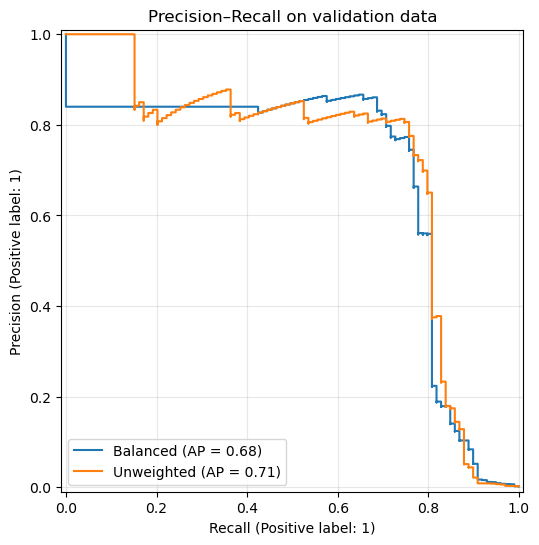

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_val, fraud_scores, name="Balanced", ax=ax
)
PrecisionRecallDisplay.from_predictions(
    y_val, unweighted_scores, name="Unweighted", ax=ax
)

ax.set_title("Precision–Recall on validation data")
ax.grid(alpha=0.3)
plt.show()